# A notebook to plot all data files created during a UM Regional Nesting Suite (RNS) run - rAM3

Let's run through the files created at every point of the rAM3 forecast suite

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import cartopy.crs as ccrs
import matplotlib.ticker as mticker
import iris
import os
import warnings

Set your `ROSE_SUITE_ID` and `NOTEBOOK_PATH` here

In [2]:
ROSE_SUITE_ID = 'rCM3-test-UM-fcst'
NOTEBOOK_PATH = ('/home/548/pag548/code/UM_config_tools/notebooks')

In [3]:
home_dir=os.environ['HOME']
HOME=Path(home_dir)

In [4]:
CYCLE = '20220226T0000Z'
WORKDIR = HOME / 'cylc-run' / ROSE_SUITE_ID / 'work'
SHAREDIR = HOME / 'cylc-run' / ROSE_SUITE_ID / 'share'
warnings.filterwarnings('ignore',module='iris') 

The first computational rAM3 rose/cylc task is to run is `ec_um_recon`. This loads the grib file `/scratch/<PROJECT>/<USER>/EC_GRIB_PARALLEL/ec_grib_202202260000.t+000` and reconfigures it  for our domain (in this case 100 x 100) by using our Land/Sea Mask ancillary. 

This task is called for every hourly grib file. Let's load the file valid at 00Z after it has been created.

In [6]:
EC_UM_DIR = SHAREDIR / 'cycle' / CYCLE / 'ec/um'
ec_recon = iris.load(EC_UM_DIR / 'ec_cb000_init')

In [9]:
# This file contains 116 variables!
ec_output = {}
long_names = []
std_names = []
var_names = []
for cube in ec_recon:
        #print (f'{file.name} {cube.long_name} {cube.standard_name} {cube.var_name}')
        long_names.append(cube.long_name)
        var_names.append(cube.var_name)
        std_names.append(cube.standard_name)
        ec_output[cube.attributes['STASH']] = { 'var_name ' : cube.var_name, 'standard_name' : cube. standard_name, 'long name' : cube.long_name }

In [10]:
print (f"The file {EC_UM_DIR / 'ec_cb000_init'} has {len(ec_output)} variables")

The file /home/548/pag548/cylc-run/rCM3-test-UM-fcst/share/cycle/20220226T0000Z/ec/um/ec_cb000_init has 116 variables


In [119]:
ec_recon

[<iris 'Cube' of m01s00i014 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i015 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i016 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i021 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i034 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i035 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i036 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i037 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i207 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i213 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i216 / (unknown) (pseudo_level: 9; latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i225 / (unknown) (pseudo_level: 5; latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i229 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i230 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i233 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i234 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i236 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i237 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i238 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i239 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i240 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i246 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i259 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i260 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i261 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i262 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i263 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i264 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i348 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i376 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i390 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i397 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i398 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i490 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i491 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i492 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i493 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i005 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i006 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i017 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i018 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i022 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of Convective cloud amount with anvil / (1) (model_level_number: 70; latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i212 / (unknown) (model_level_number: 70; latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i253 / (unknown) (model_level_number: 70; latitude: 100; longitude: 100)>,
<iris 'Cube' of cloud_volume_fraction_in_atmosphere_layer / (1) (model_level_number: 71; latitude: 100; longitude: 100)>,
<iris 'Cube' of liquid_cloud_volume_fraction_in_atmosphere_layer / (1) (model_level_number: 71; latitude: 100; longitude: 100)>,
<iris 'Cube' of ice_cloud_volume_fraction_in_atmosphere_layer / (1) (model_level_number: 71; latitude: 100; longitude: 100)>,
<iris 'Cube' of mass_concentration_of_biogenic_nmvoc_in_air / (kg/kg) (model_level_number: 71; latitude: 100; longitude: 100)>,
<iris 'Cube' of mass_fraction_of_fresh_biomass_burning_dry_aerosol_in_air / (kg/kg) (

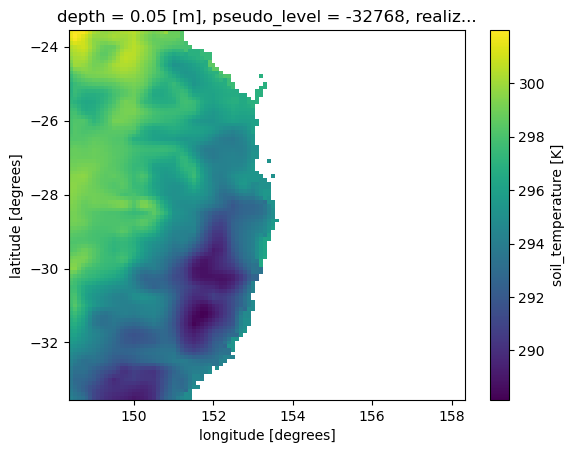

In [11]:
xr.DataArray.from_iris(ec_recon[99][0]).plot()

The subsequent task `nci_hres_eccb` then replaces the land surface fields at 0.1 resolution (or 0.11 resolution) of the 00Z file only (`ec_cb000`)
epending on the source (ERA5 or BARRA). The impacts of these updates can't be seen on our grids.

Let's reload this file after `nci_hres_eccb` has completed.

In [12]:
ec_recon_hres = iris.load(EC_UM_DIR / 'ec_cb000_hres')

In [13]:
ec_output_hres = {}
long_names = []
std_names = []
var_names = []
for cube in ec_recon_hres:
        #print (f'{file.name} {cube.long_name} {cube.standard_name} {cube.var_name}')
        long_names.append(cube.long_name)
        var_names.append(cube.var_name)
        std_names.append(cube.standard_name)
        ec_output_hres[cube.attributes['STASH']] = { 'var_name ' : cube.var_name, 'standard_name' : cube. standard_name, 'long name' : cube.long_name }

In [14]:
print (f"The file {EC_UM_DIR / 'ec_cb000'} has {len(ec_output_hres)} variables")

The file /home/548/pag548/cylc-run/rCM3-test-UM-fcst/share/cycle/20220226T0000Z/ec/um/ec_cb000 has 116 variables


The STASH in this file hasn't changed

In [126]:
ec_output_hres.keys() - ec_output.keys()

set()

But we can see an improved resoution in soil temperature, for example

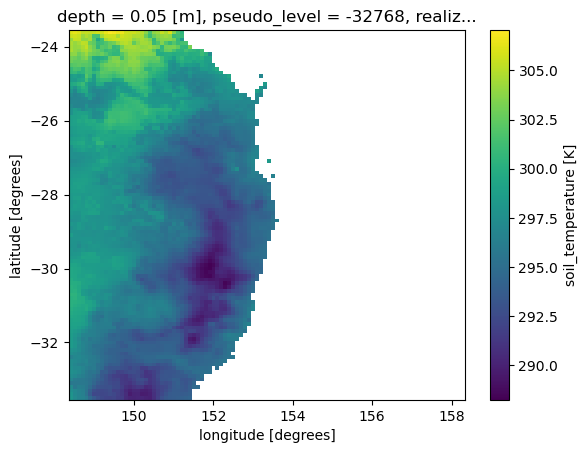

In [16]:
xr.DataArray.from_iris(ec_recon_hres[99][0]).plot()

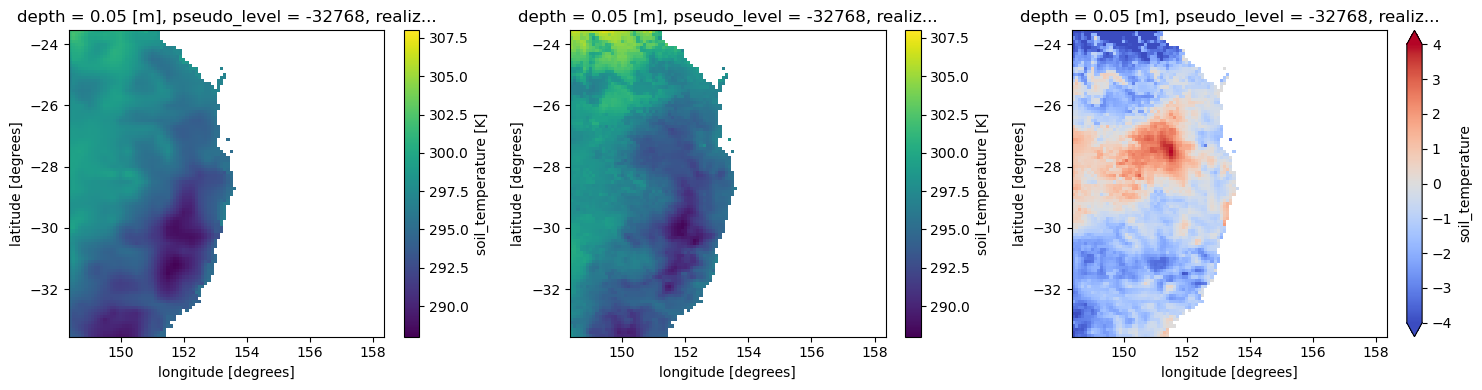

In [29]:
fig,ax=plt.subplots(1,3,figsize=(15,4))
xr.DataArray.from_iris(ec_recon[99][0]).plot(ax=ax[0],vmin=288,vmax=308)
xr.DataArray.from_iris(ec_recon_hres[99][0]).plot(ax=ax[1],vmin=288,vmax=308)
delta = xr.DataArray.from_iris(ec_recon[99][0]) - xr.DataArray.from_iris(ec_recon_hres[99][0])
delta.plot(ax=ax[2],cmap='coolwarm',vmin=-4,vmax=4)
plt.tight_layout()

Note the other reconfigured EC initial conditions remain unchanged. 

In [30]:
ec_recon_001 = iris.load(EC_UM_DIR / 'ec_cb001')

In [31]:
ec_output_001 = {}
long_names = []
std_names = []
var_names = []
for cube in ec_recon_001:
        #print (f'{file.name} {cube.long_name} {cube.standard_name} {cube.var_name}')
        long_names.append(cube.long_name)
        var_names.append(cube.var_name)
        std_names.append(cube.standard_name)
        ec_output_001[cube.attributes['STASH']] = { 'var_name ' : cube.var_name, 'standard_name' : cube. standard_name, 'long name' : cube.long_name }

In [32]:
# The STASH in this file hasn't changed
ec_output_hres.keys() - ec_output_001.keys()

set()

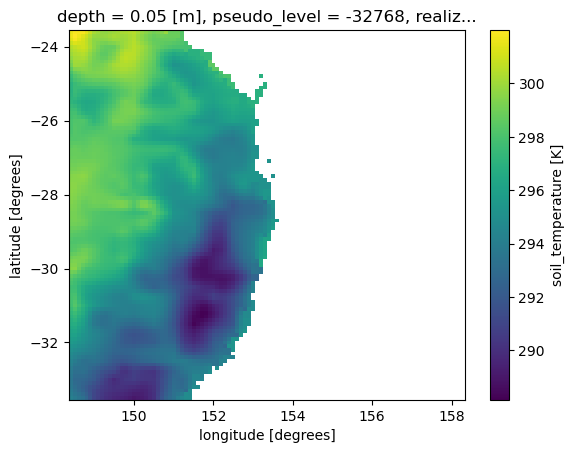

In [33]:
xr.DataArray.from_iris(ec_recon_001[99][0]).plot()

The next task to run is the `um_recon` task. This creates the ASTART file

In [34]:
GAL9_DIR = SHAREDIR / 'cycle' / CYCLE / 'Test_Ocean/test/GAL9'
ASTART_FILE = GAL9_DIR / 'ics/GAL9_astart_init'
astart_cube = iris.load(ASTART_FILE)

In [35]:
# This file contains 167 variables on our 50x50 forecast grid
ASTART_output = {}
long_names = []
std_names = []
var_names = []
for cube in astart_cube:
        #print (f'{file.name} {cube.long_name} {cube.standard_name} {cube.var_name}')
        long_names.append(cube.long_name)
        var_names.append(cube.var_name)
        std_names.append(cube.standard_name)
        ASTART_output[cube.attributes['STASH']] = { 'var_name ' : cube.var_name, 'standard_name' : cube. standard_name, 'long name' : cube.long_name }

In [36]:
len(ASTART_output)

167

In [37]:
astart_cube

[<iris 'Cube' of m01s00i014 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i015 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i016 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i021 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i034 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i035 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i036 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i037 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i096 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i207 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i213 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i216 / (unknown) (pseudo_level: 9; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i221 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i225 / (unknown) (pseudo_level: 5; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i229 / (unknown) (pseudo_level: 9; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i230 / (unknown) (pseudo_level: 9; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i233 / (unknown) (pseudo_level: 9; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i234 / (unknown) (pseudo_level: 9; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i236 / (unknown) (pseudo_level: 9; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i237 / (unknown) (pseudo_level: 9; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i238 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i239 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i240 / (unknown) (pseudo_level: 9; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i241 / (unknown) (pseudo_level: 9; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i242 / (unknown) (pseudo_level: 9; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i259 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i260 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i261 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i262 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i263 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i264 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i274 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i275 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i276 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i277 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i278 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i279 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i280 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i281 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i282 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i283 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i284 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i285 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i348 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i376 / (unknown) (pseudo_level: 9; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i377 / (unknown) (pseudo_level: 9; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i380 / (unknown) (pseudo_level: 9; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i381 / (unknown) (pseudo_level: 27; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i382 / (unknown) (pseudo_level: 27; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i383 / (unknown) (pseudo_level: 27; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i384 / (unknown) (pseudo_level: 27; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i385 / (unknown) (pseudo_level: 27; latitude: 

Let's load up the soil temperature on the forecast grid.

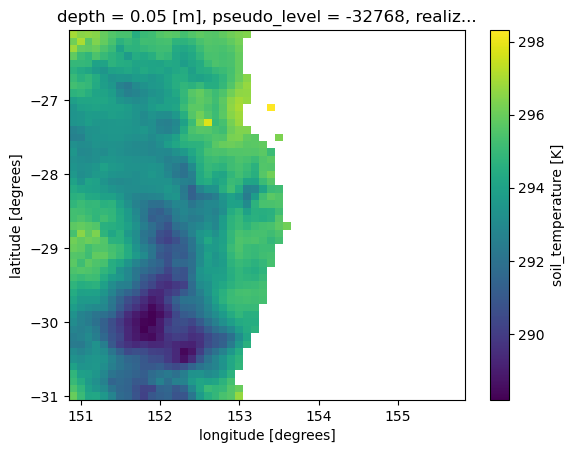

In [38]:
xr.DataArray.from_iris(astart_cube[150][0]).plot()

Now the ASTART file exists, we can run `nci_hres_ic`. This modifies the ASTART file. Let's load the file again and compare it

In [39]:
ASTART_FILE = GAL9_DIR / 'ics/GAL9_astart_hres'
astart_hres_cube = iris.load(ASTART_FILE)

ASTART_hres_output = {}
long_names = []
std_names = []
var_names = []
for cube in astart_hres_cube:
        #print (f'{file.name} {cube.long_name} {cube.standard_name} {cube.var_name}')
        long_names.append(cube.long_name)
        var_names.append(cube.var_name)
        std_names.append(cube.standard_name)
        ASTART_hres_output[cube.attributes['STASH']] = { 'var_name ' : cube.var_name, 'standard_name' : cube. standard_name, 'long name' : cube.long_name }

In [40]:
len(ASTART_hres_output)

167

In [41]:
# The STASH in this file hasn't changed
ASTART_hres_output.keys() - ASTART_output.keys()

set()

In [42]:
#Which files have?
for i in range(len(astart_cube)):
    base_cube = astart_cube[i]
    hres_cube = astart_hres_cube[i]
    delta = base_cube.data.mean() - hres_cube.data.mean()
    if np.abs(delta) > 0.0001:
        print (f'i={i}, {base_cube.name()}, \t base mean = {base_cube.data.mean():.3f}, \t hres_mean = {hres_cube.data.mean():.3f}, Delta = {delta}')
print (f'\n')

i=140, moisture_content_of_soil_layer, 	 base mean = 243.425, 	 hres_mean = 246.339, Delta = -2.9143145161290533
i=150, soil_temperature, 	 base mean = 293.978, 	 hres_mean = 293.889, Delta = 0.08855459057070902




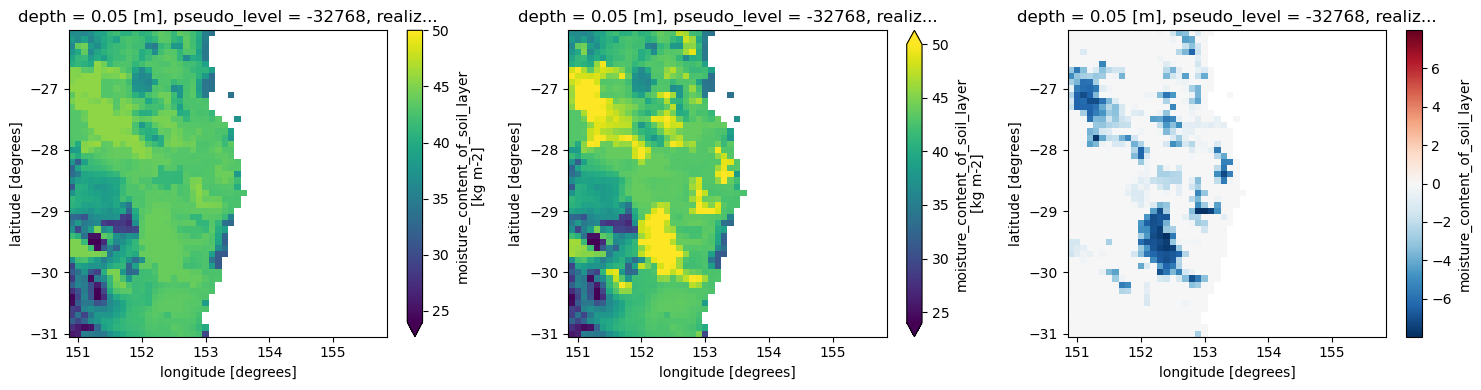

In [45]:
#Plot these differences
fig,ax=plt.subplots(1,3,figsize=(15,4))
xr.DataArray.from_iris(astart_cube[140][0]).plot(ax=ax[0],vmin=24,vmax=50)
xr.DataArray.from_iris(astart_hres_cube[140][0]).plot(ax=ax[1],vmin=24,vmax=50)
delta = xr.DataArray.from_iris(astart_cube[140][0]) - xr.DataArray.from_iris(astart_hres_cube[140][0])
delta.plot(ax=ax[2])
plt.tight_layout()

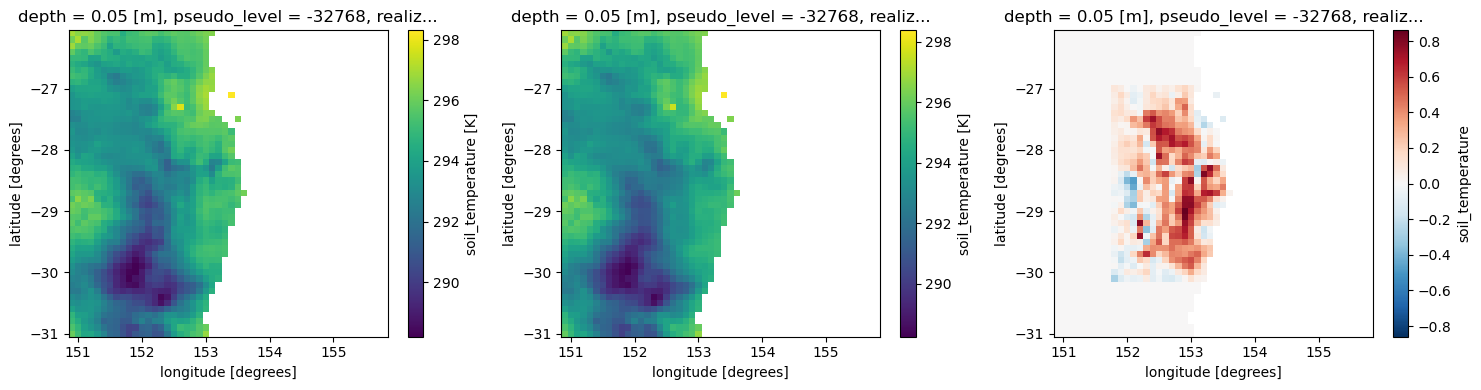

In [48]:
#Plot these differences
fig,ax=plt.subplots(1,3,figsize=(15,4))
xr.DataArray.from_iris(astart_cube[150][0]).plot(ax=ax[0])
xr.DataArray.from_iris(astart_hres_cube[150][0]).plot(ax=ax[1])
delta = xr.DataArray.from_iris(astart_cube[150][0]) - xr.DataArray.from_iris(astart_hres_cube[150][0])
delta.plot(ax=ax[2])
plt.tight_layout()

I can see no change for this field.

Now we can build the LBCs for the first few hours of our forecast. Unfortunately this file won't load in iris


In [49]:
LBC_FILE = GAL9_DIR / 'lbcs/GAL9_alabc_000'
LBC = iris.load(LBC_FILE)

TypeError: unsupported format string passed to SplittableInt.__format__

In [50]:
LBC_FILE

PosixPath('/home/548/pag548/cylc-run/rCM3-test-UM-fcst/share/cycle/20220226T0000Z/Test_Ocean/test/GAL9/lbcs/GAL9_alabc_000')

Let's try the low level mule library and read the binary values directly.

In [51]:
import mule

In [52]:
ff = mule.FieldsFile.from_file(str(LBC_FILE))

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.12/lib/python3.11/site-packages/mule/stashmaster.py:259: UserWarning: 
Unable to load STASHmaster from version string, path does not exist
Path: $UMDIR/vn13.5/ctldata/STASHmaster/STASHmaster_A
Please check that the value of mule.stashmaster.STASHMASTER_PATH_PATTERN is correct for your site/configuration
  warnings.warn(msg)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.12/lib/python3.11/site-packages/mule/validators.py:198: UserWarning: 
File: /home/548/pag548/cylc-run/rCM3-test-UM-fcst/share/cycle/20220226T0000Z/Test_Ocean/test/GAL9/lbcs/GAL9_alabc_000
Incorrect dataset_type (found 5, should be one of (3,))
  warnings.warn(msg)


Ok even mule has complains. Let's just plot the ouputs from `xconv`

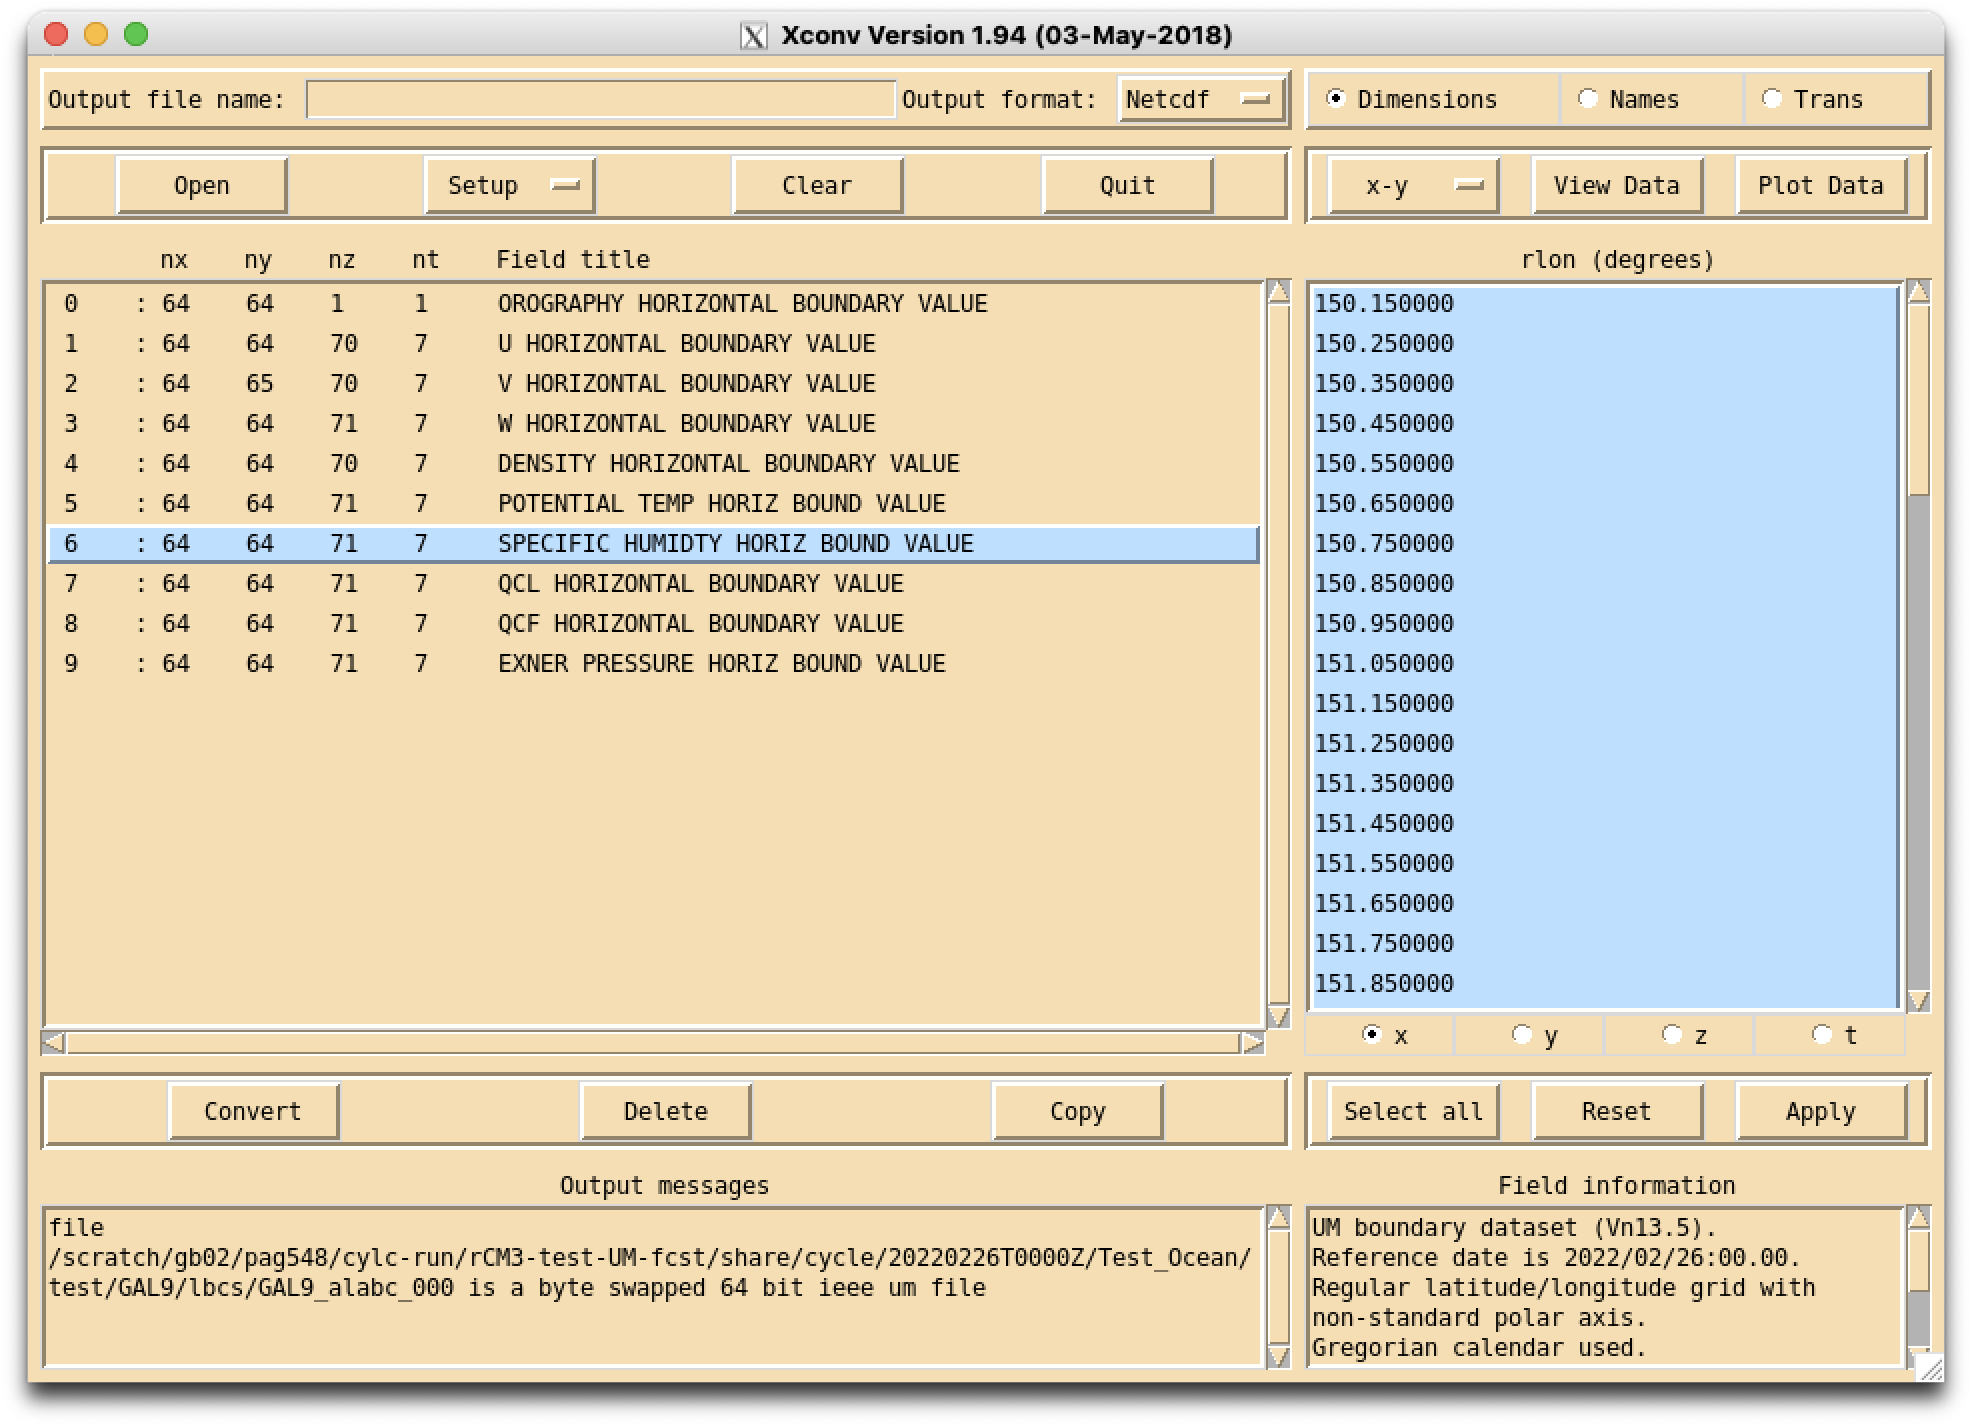

In [21]:
from IPython.display import Image, display
display(Image(filename=str(NOTEBOOK_PATH)+ '/images/LBC_fields.png'))

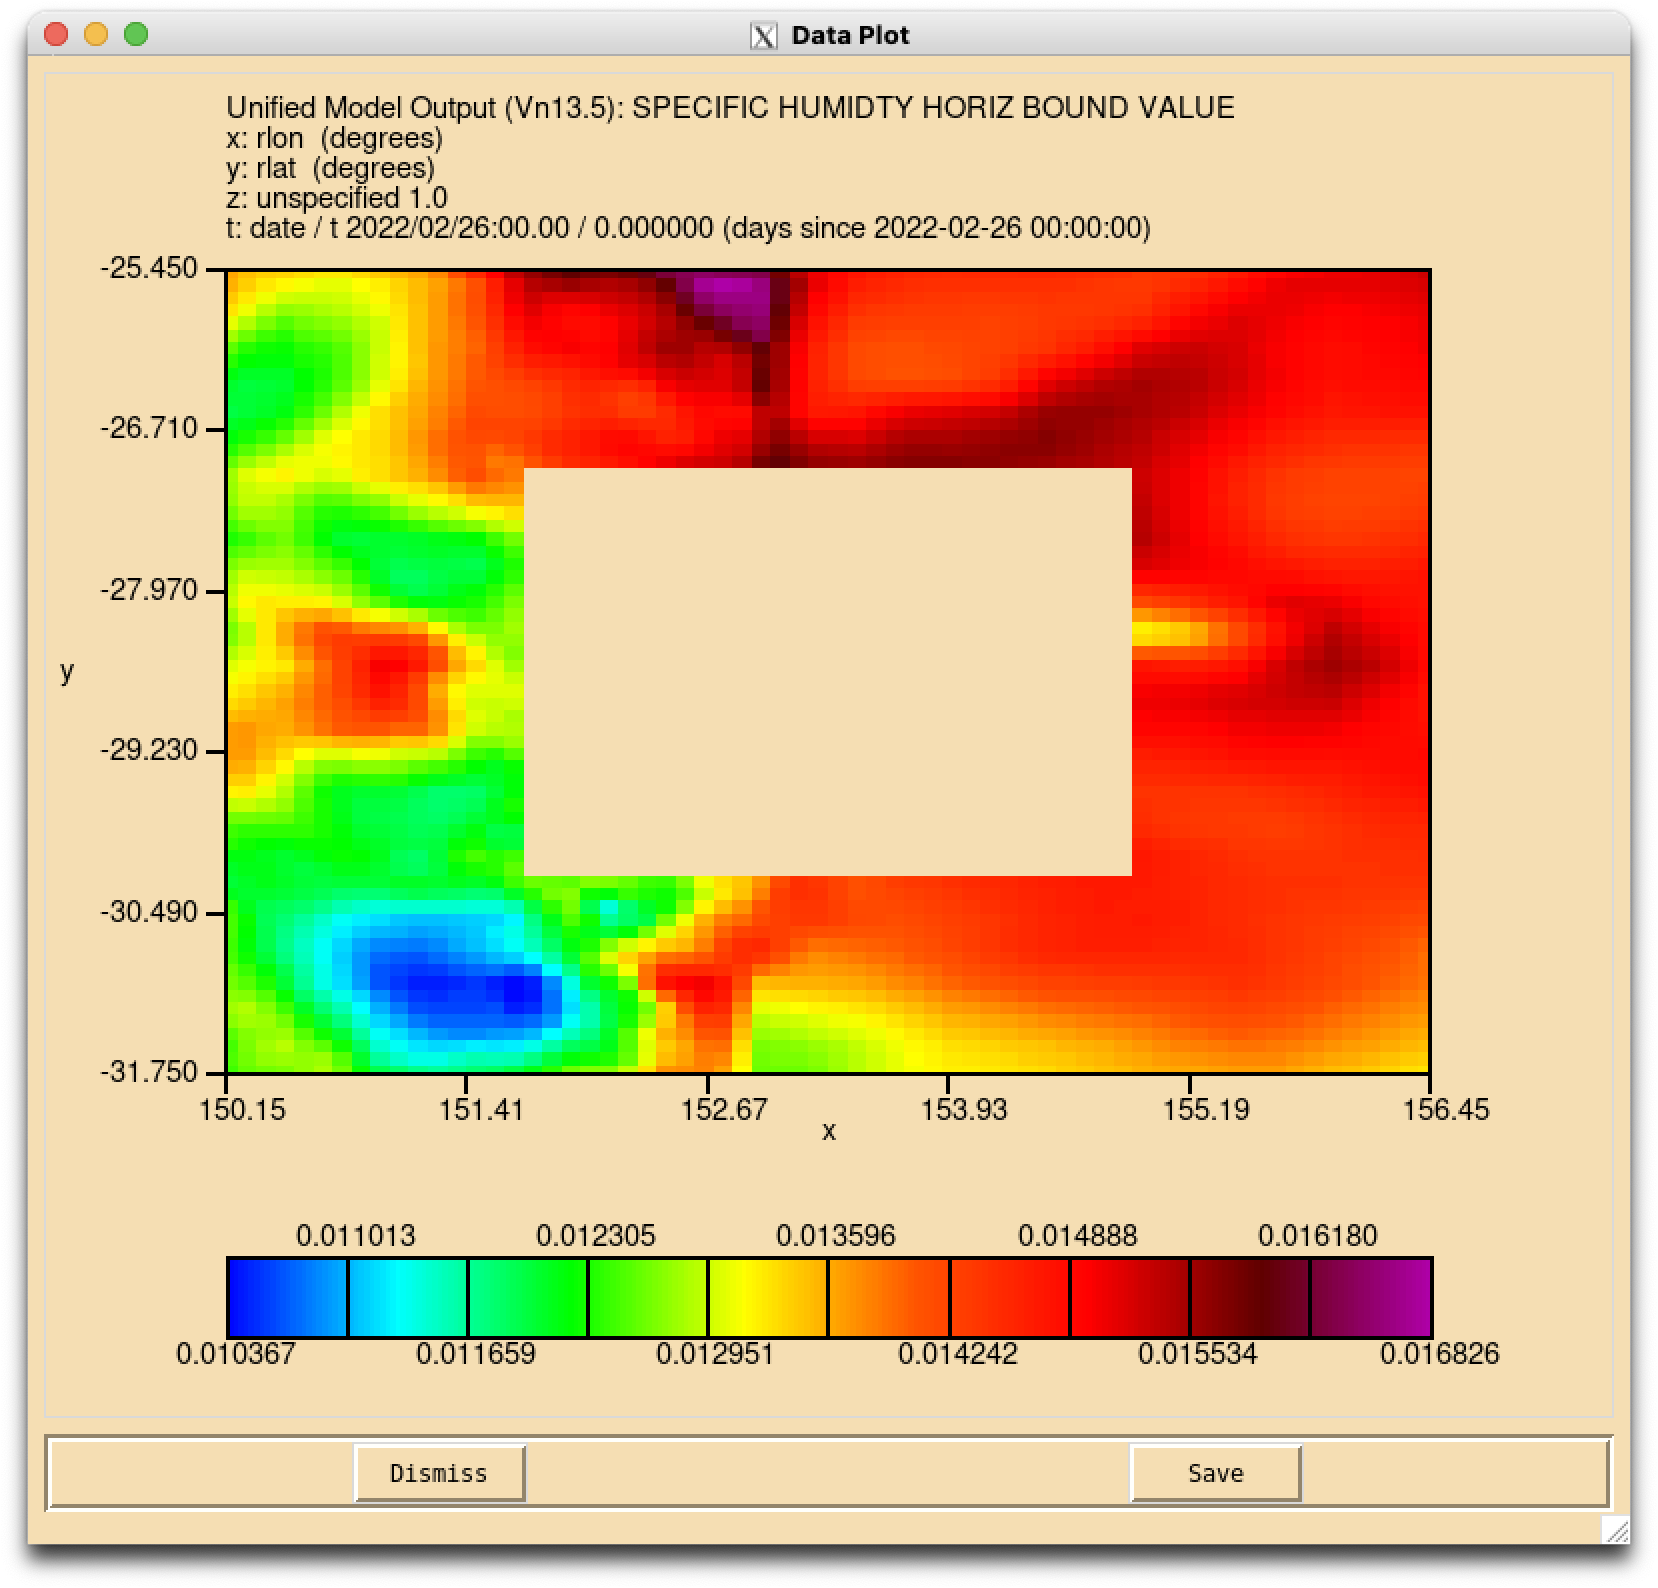

In [53]:
display(Image(filename=str(NOTEBOOK_PATH)+ '/images/LBC_plot.png'))

Now we can run a forecast task. This produces an extra initial condition file

In [55]:
UM_NSAA_DA_FILE = GAL9_DIR / 'ics/umnsaa_da006'
UM_NSAA_DA = iris.load(UM_NSAA_DA_FILE)

In [56]:
UM_NSAA_DA

[<iris 'Cube' of m01s00i014 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i015 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i016 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i021 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i034 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i035 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i036 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i037 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i096 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i207 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i213 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i216 / (unknown) (pseudo_level: 9; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i221 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i225 / (unknown) (pseudo_level: 5; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i229 / (unknown) (pseudo_level: 9; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i230 / (unknown) (pseudo_level: 9; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i233 / (unknown) (pseudo_level: 9; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i234 / (unknown) (pseudo_level: 9; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i236 / (unknown) (pseudo_level: 9; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i237 / (unknown) (pseudo_level: 9; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i238 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i239 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i240 / (unknown) (pseudo_level: 9; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i241 / (unknown) (pseudo_level: 9; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i242 / (unknown) (pseudo_level: 9; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i259 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i260 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i261 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i262 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i263 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i264 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i274 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i275 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i276 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i277 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i278 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i279 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i280 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i281 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i282 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i283 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i284 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i285 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i348 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i376 / (unknown) (pseudo_level: 9; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i377 / (unknown) (pseudo_level: 9; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i380 / (unknown) (pseudo_level: 9; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i381 / (unknown) (pseudo_level: 27; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i382 / (unknown) (pseudo_level: 27; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i383 / (unknown) (pseudo_level: 27; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i384 / (unknown) (pseudo_level: 27; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i385 / (unknown) (pseudo_level: 27; latitude: 

Here are the standard forecast outputs. Each contain a variety of fields on model levels and pressure levels

In [62]:
UM_NSAA_PA_FILE = GAL9_DIR / 'um/umnsaa_pa000'
UM_NSAA_PA = iris.load(UM_NSAA_PA_FILE)

In [63]:
UM_NSAA_PA

[<iris 'Cube' of land_binary_mask / (1) (latitude: 50; longitude: 50)>,
<iris 'Cube' of surface_altitude / (m) (latitude: 50; longitude: 50)>]

In [64]:
UM_NSAA_PB_FILE = GAL9_DIR / 'um/umnsaa_pb000'
UM_NSAA_PB = iris.load(UM_NSAA_PB_FILE)

In [65]:
UM_NSAA_PB

[<iris 'Cube' of air_pressure_at_sea_level / (Pa) (time: 180; latitude: 50; longitude: 50)>,
<iris 'Cube' of convective_rainfall_amount / (kg m-2) (time: 180; latitude: 50; longitude: 50)>,
<iris 'Cube' of stratiform_rainfall_amount / (kg m-2) (time: 180; latitude: 50; longitude: 50)>,
<iris 'Cube' of wind_speed_of_gust / (m s-1) (time: 180; latitude: 50; longitude: 50)>]

In [66]:
UM_NSAA_CB_FILE = GAL9_DIR / 'um/umnsaa_cb000'
UM_NSAA_CB = iris.load(UM_NSAA_CB_FILE)

In [67]:
UM_NSAA_CB

M01S00I253 (unknown),model_level_number,time,latitude,longitude
Shape,70,2,50,50
Dimension coordinates,,,,
model_level_number,x,-,-,-
time,-,x,-,-
latitude,-,-,x,-
longitude,-,-,-,x
Auxiliary coordinates,,,,
level_height,x,-,-,-
sigma,x,-,-,-
forecast_period,-,x,-,-


etc.

Here is a summary of the task and data flow.

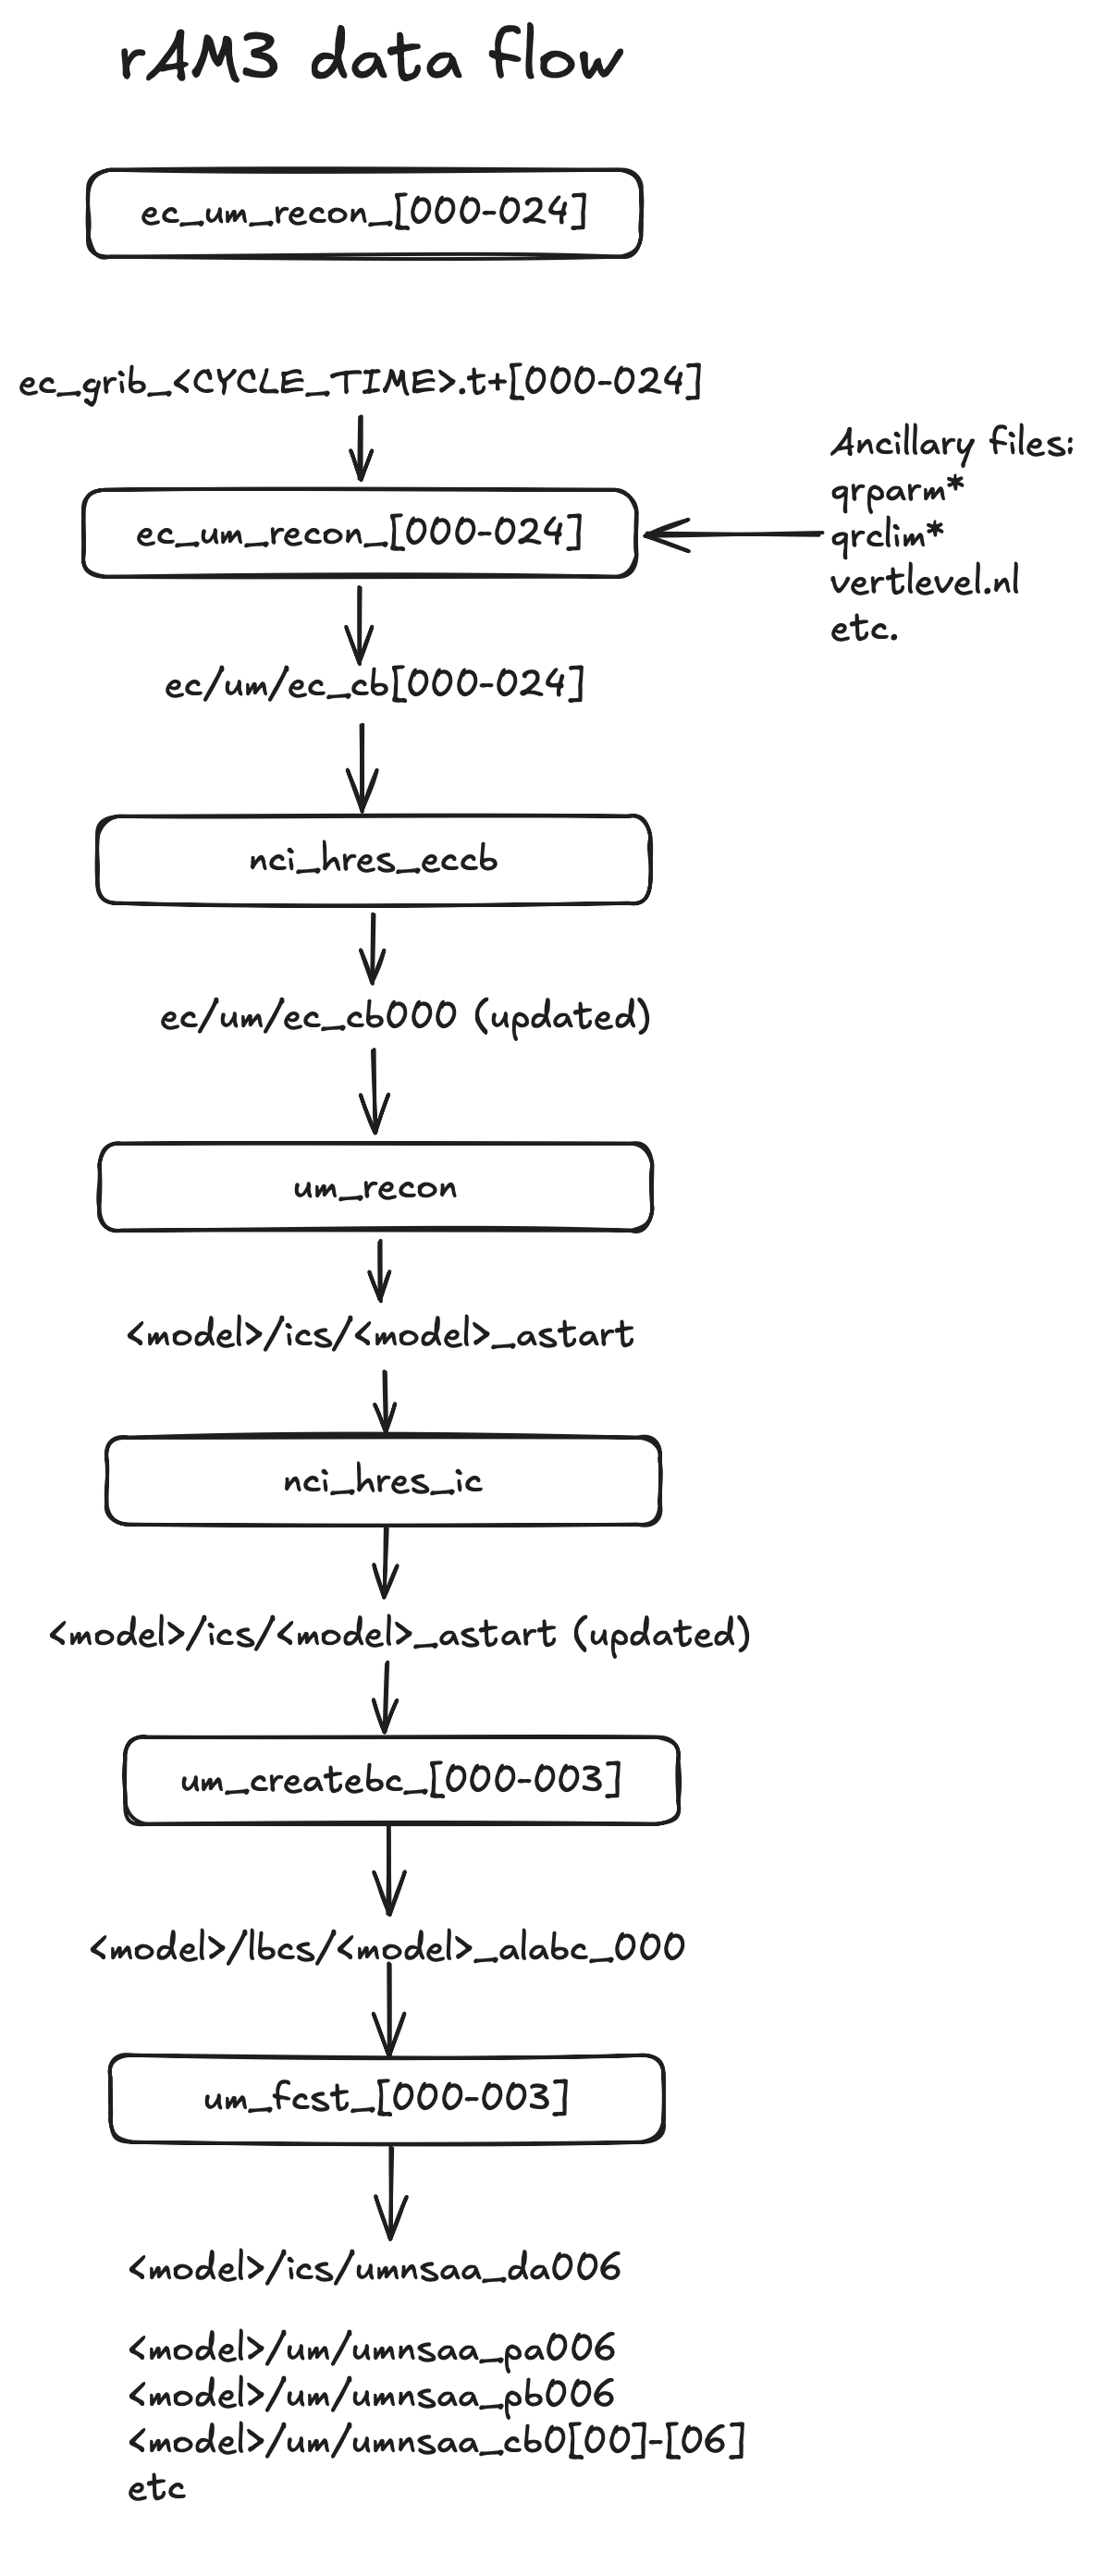

In [22]:
display(Image(filename=str(NOTEBOOK_PATH)+ '/images/rAM3-data-flow.png'))